# Phase 0 — Data pipeline

**Project:** Latent mood & user-taste modelling with MSD audio features and Last.fm listening histories.

**Goal of this notebook:** turn the two raw datasets into the two clean CSVs that every later phase consumes:

- `data/songs_clean.csv` — one row per matched song, six audio features normalised to $[0,1]$.
- `data/listens_clean.csv` — one row per (user, song) pair, with `play_count` and `listened` (0/1).

**Inputs** (must already be extracted on disk):

- `data/lastfm1k/userid-timestamp-artid-artname-traid-traname.tsv` (~1.3 GB)
- `data/msd/MillionSongSubset/A/B/C/TR…h5` (10 000 files, ~2.6 GB)

**Pipeline** (joins on normalised `(artist_name, track_title)`):

1. Load Last.fm scrobbles → DataFrame.
2. Walk MSD HDF5 tree, pull six audio features per song → DataFrame.
3. Normalise artist/track strings on both sides.
4. Inner-join MSD × Last.fm — matched corpus.
5. Aggregate listen events; keep users with ≥5 listens in the matched corpus.
6. Sample 5 negatives per positive listen.
7. MinMax-scale the six features to $[0,1]$.
8. Save the two CSVs.
9. EDA: corpus size, listen-count distribution, feature correlation heatmap, feature histograms.


## 0  Imports & global config


In [1]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from pathlib import Path

np.random.seed(42)
plt.style.use('ggplot')
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)

REPO_ROOT       = Path.cwd()
DATA_DIR        = REPO_ROOT / 'data'
DATA_DIR.mkdir(exist_ok=True)

LASTFM_DIR      = REPO_ROOT.parent / 'lastfm-dataset-1K'
MSD_SUMMARY     = REPO_ROOT.parent / 'msd_summary_file.h5'
TAGTRAUM        = REPO_ROOT.parent / 'msd_tagtraum_cd2.cls'
UNIQUE_TRACKS   = REPO_ROOT.parent / 'unique_tracks.txt'   # MSD TR→SO ID mapping

FEATURE_COLS = ['loudness', 'tempo', 'key', 'mode', 'time_signature', 'duration']

## 1  Load Last.fm 1K listening histories

The TSV is ~1.3 GB and ~19 M rows — every scrobble of every user. We load just the columns we need and parse timestamps. A few rows are malformed (uneven number of fields); we skip them silently.


In [2]:
lastfm_path = LASTFM_DIR / 'userid-timestamp-artid-artname-traid-traname.tsv'
df_lastfm = pd.read_csv(
    lastfm_path, sep='\t', header=None,
    names=['user_id', 'timestamp', 'artist_id', 'artist_name', 'track_id', 'track_name'],
    parse_dates=['timestamp'],
    on_bad_lines='skip',
)
print(f'Last.fm scrobbles: {len(df_lastfm):,} rows')
print(f'Unique users:      {df_lastfm["user_id"].nunique():,}')
df_lastfm.head()


Last.fm scrobbles: 19,098,853 rows
Unique users:      992


,user_id,timestamp,artist_id,artist_name,track_id,track_name
0,user_000001,2009-05-04 23:08:57+00:00,f1b1cf71-bd35-4e99-8624-24a6e15f133a,Deep Dish,NaN,Fuck Me Im Famous (Pacha Ibiza)-09-28-2007
1,user_000001,2009-05-04 13:54:10+00:00,a7f7df4a-77d8-4f12-8acd-5c60c93f4de8,坂本龍一,NaN,Composition 0919 (Live_2009_4_15)
2,user_000001,2009-05-04 13:52:04+00:00,a7f7df4a-77d8-4f12-8acd-5c60c93f4de8,坂本龍一,NaN,Mc2 (Live_2009_4_15)
3,user_000001,2009-05-04 13:42:52+00:00,a7f7df4a-77d8-4f12-8acd-5c60c93f4de8,坂本龍一,NaN,Hibari (Live_2009_4_15)
4,user_000001,2009-05-04 13:42:11+00:00,a7f7df4a-77d8-4f12-8acd-5c60c93f4de8,坂本龍一,NaN,Mc1 (Live_2009_4_15)


## 2  Load the MSD summary file

The summary file is a single HDF5 containing pre-computed Echo Nest features for all **1,000,000** songs in the full MSD. We load it in one vectorised pass with numpy — no file-tree walk needed. Note: `energy` and `danceability` are not stored in the summary file (they were only in the per-track HDF5s), so we substitute `key` (chromatic key, 0–11) and `duration` (track length in seconds).


In [3]:
with h5py.File(MSD_SUMMARY, 'r') as f:
    meta = f['metadata']['songs']
    ana  = f['analysis']['songs']
    df_msd = pd.DataFrame({
        'song_id':        [x.decode('utf-8', errors='replace') for x in meta['song_id'][:]],
        'artist_name':    [x.decode('utf-8', errors='replace') for x in meta['artist_name'][:]],
        'title':          [x.decode('utf-8', errors='replace') for x in meta['title'][:]],
        'loudness':       ana['loudness'][:].astype(float),
        'tempo':          ana['tempo'][:].astype(float),
        'key':            ana['key'][:].astype(float),
        'mode':           ana['mode'][:].astype(float),
        'time_signature': ana['time_signature'][:].astype(float),
        'duration':       ana['duration'][:].astype(float),
    })
print(f'MSD songs loaded: {len(df_msd):,}')
df_msd.head()

MSD songs loaded: 1,000,000


,song_id,artist_name,title,loudness,tempo,key,mode,time_signature,duration
0,SOQMMHC12AB0180CB8,Faster Pussy cat,Silent Night,-4.829,87.002,10.0,0.0,4.0,252.05506
1,SOVFVAK12A8C1350D9,Karkkiautomaatti,Tanssi vaan,-10.555,150.778,9.0,1.0,1.0,156.55138
2,SOGTUKN12AB017F4F1,Hudson Mohawke,No One Could Ever,-2.060,177.768,7.0,1.0,4.0,138.97098
3,SOBNYVR12A8C13558C,Yerba Brava,Si Vos Querés,-4.654,87.433,7.0,1.0,4.0,145.05751
4,SOHSBXH12A8C13B0DF,Der Mystic,Tangle Of Aspens,-7.806,140.035,5.0,0.0,4.0,514.29832


## 2.5  Load tagtraum genre annotations

The [tagtraum MSD genre dataset](https://www.tagtraum.com/msd_genre_datasets.html) provides majority-vote genre labels for ~280k MSD tracks derived from Last.fm, Top-MAGD, and the beaTunes Genre Dataset. The tagtraum file uses MSD **track IDs** (`TR...`), while the summary HDF5 stores Echo Nest **song IDs** (`SO...`). We bridge them via `unique_tracks.txt`, the official MSD mapping file (`trackID<SEP>songID<SEP>artist<SEP>title`). After resolving to `song_id`, we left-join to the matched corpus; songs with no annotation receive `genre = "Unknown"`. These labels seed the genre-stratified K-means warm-start in Phase 1, enabling K=6 without component collapse.

In [4]:
# TR→SO mapping from unique_tracks.txt
df_tracks = pd.read_csv(
    UNIQUE_TRACKS, sep='<SEP>', header=None,
    names=['track_id', 'song_id', 'artist', 'title'],
    engine='python',
)

# Tagtraum genre labels (TR... IDs) joined through the mapping to SO... IDs
df_genre_raw = pd.read_csv(
    TAGTRAUM, sep='\t', comment='#', header=None,
    names=['track_id', 'genre', 'genre_minor'],
    dtype=str,
)
df_genre = (df_genre_raw[['track_id', 'genre']]
            .merge(df_tracks[['track_id', 'song_id']], on='track_id', how='left')
            [['song_id', 'genre']]
            .dropna(subset=['song_id']))

print(f'Tagtraum genres resolved: {len(df_genre):,} songs')
print(f'Unique majority genres:   {df_genre["genre"].nunique()}')
print(df_genre['genre'].value_counts().to_string())

Tagtraum genres resolved: 280,831 songs
Unique majority genres:   15
genre
Rock          113150
Electronic     30922
Pop            27756
Jazz           17541
Rap            13272
RnB            13208
Metal          11222
Country        10695
Reggae          8910
Blues           8125
Latin           6444
Folk            6377
Punk            5652
World           4770
New Age         2787


## 3  Normalise artist & track strings

Last.fm and MSD store artist + title as free-form strings and often differ in formatting. We apply two-stage normalisation: first strip anything after a `(` or `[` and after ` - ` (removing live recordings, remasters, and alternate-version tags that MSD appends but Last.fm users omit), then lowercase, strip whitespace, and replace `-`/`_` with spaces. This raises the scrobble match rate from ~35% (basic) to ~46% (~8.7M matched rows).


In [5]:
import re

def normalise_str(s):
    """Lowercase + strip live/remaster/version suffixes so MSD and Last.fm titles align."""
    if not isinstance(s, str):
        return ''
    s = re.sub(r'\s*[\(\[].*', '', s)          # drop everything after ( or [
    s = re.sub(r'\s+-\s+.*$', '', s, flags=re.IGNORECASE)  # drop ' - Live', ' - Remaster' etc.
    return s.lower().strip().replace('-', ' ').replace('_', ' ')

df_lastfm['artist_norm'] = df_lastfm['artist_name'].map(normalise_str)
df_lastfm['track_norm']  = df_lastfm['track_name'].map(normalise_str)
df_msd['artist_norm']    = df_msd['artist_name'].map(normalise_str)
df_msd['track_norm']     = df_msd['title'].map(normalise_str)


## 4  Inner-join MSD × Last.fm — matched corpus

Inner join on `(artist_norm, track_norm)`. We keep only songs that appear in BOTH datasets — this is the working corpus for every downstream phase.


In [6]:
lastfm_pairs = df_lastfm[['artist_norm', 'track_norm']].drop_duplicates()
df_songs = df_msd.merge(lastfm_pairs, on=['artist_norm', 'track_norm'], how='inner')
df_songs = df_songs.drop_duplicates(subset='song_id').reset_index(drop=True)
print(f'Matched corpus size: {len(df_songs):,} songs')


Matched corpus size: 292,254 songs


In [7]:
df_songs = df_songs.merge(df_genre[['song_id', 'genre']], on='song_id', how='left')
df_songs['genre'] = df_songs['genre'].fillna('Unknown')
n_annotated = (df_songs['genre'] != 'Unknown').sum()
print(f'Genre coverage: {n_annotated:,} of {len(df_songs):,} matched songs ({100*n_annotated/len(df_songs):.1f}%)')
print(df_songs['genre'].value_counts().to_string())

Genre coverage: 157,432 of 292,254 matched songs (53.9%)
genre
Unknown       134822
Rock           72062
Electronic     19902
Pop            15621
Metal           8121
Rap             6987
Jazz            6866
RnB             5945
Reggae          4081
Country         3678
Punk            3448
Folk            3101
Blues           2442
Latin           2087
World           1948
New Age         1143


## 5  Active users & positive listen events

Aggregate Last.fm scrobbles into `(user, song)` play counts within the matched corpus. Drop users with fewer than 5 listens — they don't carry enough signal for a per-user taste profile.


In [8]:
df_events = df_lastfm[['user_id', 'artist_norm', 'track_norm']].merge(
    df_songs[['song_id', 'artist_norm', 'track_norm']],
    on=['artist_norm', 'track_norm'], how='inner'
)
df_listens_pos = (
    df_events.groupby(['user_id', 'song_id'])
             .size().reset_index(name='play_count')
)
df_listens_pos['listened'] = 1

user_counts = df_listens_pos.groupby('user_id')['song_id'].count()
active_users = user_counts[user_counts >= 5].index
df_listens_pos = df_listens_pos[df_listens_pos['user_id'].isin(active_users)]
print(f'Active users (>=5 listens in matched corpus): {len(active_users):,}')
print(f'Positive listen events:                       {len(df_listens_pos):,}')


Active users (>=5 listens in matched corpus): 988
Positive listen events:                       2,801,783


## 6  Negative sampling at 5:1

For every positive listen $l_{us}=1$, we draw 5 songs the user did NOT listen to and label them $l_{us}=0$. This balances the implicit-feedback Bernoulli likelihood in later phases.


In [9]:
all_song_ids = df_songs['song_id'].to_numpy()
negatives = []
for user_id in active_users:
    pos = set(df_listens_pos.loc[df_listens_pos['user_id'] == user_id, 'song_id'])
    neg_pool = [s for s in all_song_ids if s not in pos]
    n_neg = min(5 * len(pos), len(neg_pool))
    if n_neg == 0:
        continue
    sampled = np.random.choice(neg_pool, n_neg, replace=False)
    for s in sampled:
        negatives.append({'user_id': user_id, 'song_id': s, 'play_count': 0, 'listened': 0})
df_negs = pd.DataFrame(negatives)
df_listens = pd.concat([df_listens_pos, df_negs], ignore_index=True)
print(f'Total listen events (pos + neg): {len(df_listens):,}')
print(f'  positives: {(df_listens["listened"]==1).sum():,}')
print(f'  negatives: {(df_listens["listened"]==0).sum():,}')


Total listen events (pos + neg): 16,810,698
  positives: 2,801,783
  negatives: 14,008,915


In [10]:
df_songs = df_songs.dropna(subset=FEATURE_COLS).reset_index(drop=True)
scaler = MinMaxScaler()
df_songs[FEATURE_COLS] = scaler.fit_transform(df_songs[FEATURE_COLS])
df_songs[FEATURE_COLS].describe().T


,count,mean,std,min,25%,50%,75%,max
loudness,292254.0,0.776539,0.077165,0.0,0.738151,0.793743,0.831639,1.0
tempo,292254.0,0.447736,0.122125,0.0,0.356310,0.441619,0.517716,1.0
key,292254.0,0.486579,0.328613,0.0,0.181818,0.545455,0.818182,1.0
mode,292254.0,0.657544,0.474532,0.0,0.000000,1.000000,1.000000,1.0
time_signature,292254.0,0.518202,0.168730,0.0,0.571429,0.571429,0.571429,1.0
duration,292254.0,0.084441,0.039085,0.0,0.062167,0.077838,0.098360,1.0


## 8  Save the two clean CSVs

These two files are the inputs for every later phase. They are committed to the repo so the model notebook can be re-run without redoing Phase 0.


In [11]:
songs_out = DATA_DIR / 'songs_clean.csv'
listens_out = DATA_DIR / 'listens_clean.csv'

songs_keep = ['song_id', 'artist_name', 'title', 'genre'] + FEATURE_COLS
df_songs[songs_keep].to_csv(songs_out, index=False)
df_listens[['user_id', 'song_id', 'play_count', 'listened']].to_csv(listens_out, index=False)

print(f'Wrote {songs_out}: {len(df_songs):,} songs')
print(f'Wrote {listens_out}: {len(df_listens):,} listen events')

Wrote /Users/magle/Desktop/Repos/MBML---2026/data/songs_clean.csv: 292,254 songs
Wrote /Users/magle/Desktop/Repos/MBML---2026/data/listens_clean.csv: 16,810,698 listen events


## 9  Exploratory data analysis

### 9.1 Listen-count distribution per user

Heavy right tail is expected — a handful of power users with thousands of listens, a long tail of light users.


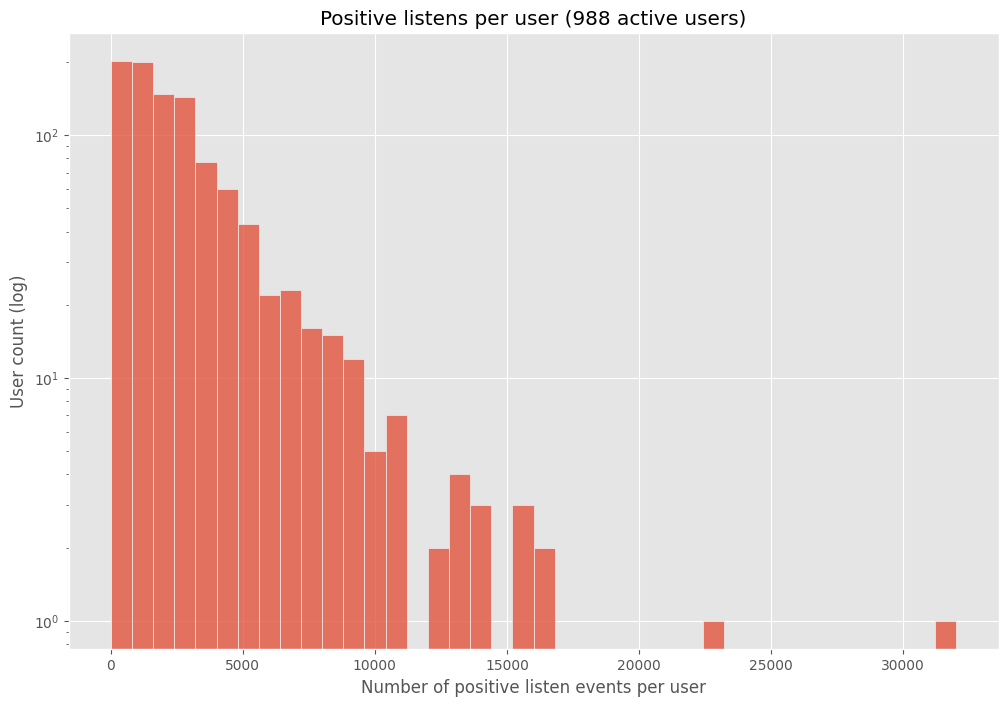

count      988.000000
mean      2835.812753
std       2860.435260
min          6.000000
25%        953.000000
50%       2071.000000
75%       3664.750000
max      32014.000000
dtype: float64


In [12]:
user_listens = df_listens_pos.groupby('user_id').size()
sns.histplot(user_listens, bins=40)
plt.yscale('log')
plt.xlabel('Number of positive listen events per user')
plt.ylabel('User count (log)')
plt.title(f'Positive listens per user ({len(active_users):,} active users)')
plt.show()

print(user_listens.describe())

### 9.2 Feature correlation heatmap

Check that the six audio features are not perfectly collinear (which would cause issues with the multivariate-Gaussian covariance in Phase 1).


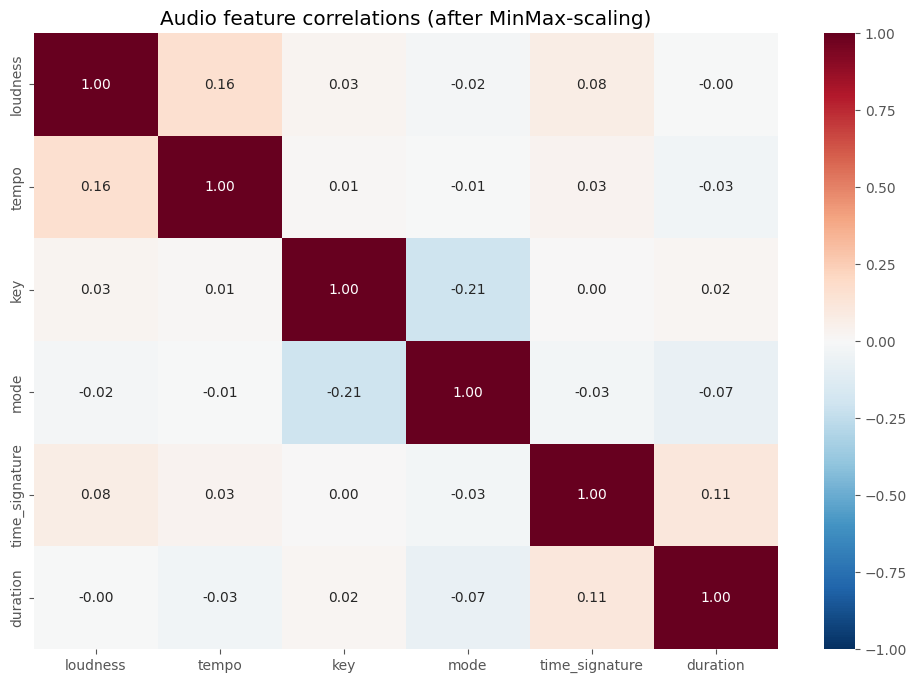

In [13]:
corr = df_songs[FEATURE_COLS].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1)
plt.title('Audio feature correlations (after MinMax-scaling)')
plt.show()


### 9.3 Feature histograms

Per-feature distribution after scaling — useful sanity check that `mode` and `time_signature` (categorical-ish features) didn't get crushed by the scaler.


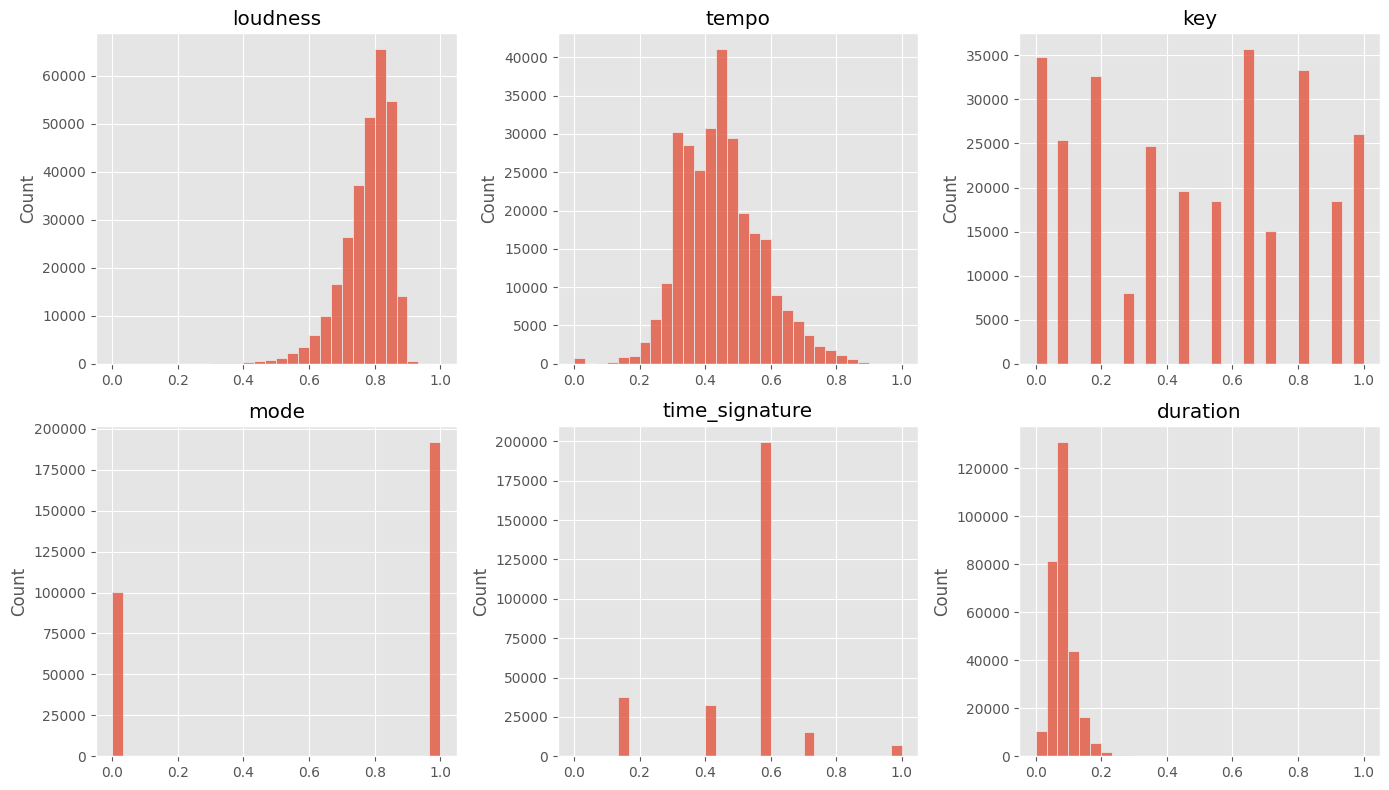

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, FEATURE_COLS):
    sns.histplot(df_songs[col], bins=30, ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')
plt.tight_layout()
plt.show()


### 9.4 Summary

Final printout for the Phase 0 gate (master prompt requires this before moving to Phase 1):


In [15]:
print('=' * 60)
print('PHASE 0 SUMMARY')
print('=' * 60)
print(f'Matched corpus size:        {len(df_songs):,} songs')
print(f'Active users (>=5 listens): {len(active_users):,}')
print(f'Positive listen events:     {(df_listens["listened"]==1).sum():,}')
print(f'Negative listen events:     {(df_listens["listened"]==0).sum():,}')
print()
print('Per-feature stats (MinMax-scaled):')
print(df_songs[FEATURE_COLS].describe().T[['mean', 'std', 'min', 'max']])


PHASE 0 SUMMARY
Matched corpus size:        292,254 songs
Active users (>=5 listens): 988
Positive listen events:     2,801,783
Negative listen events:     14,008,915

Per-feature stats (MinMax-scaled):
                    mean       std  min  max
loudness        0.776539  0.077165  0.0  1.0
tempo           0.447736  0.122125  0.0  1.0
key             0.486579  0.328613  0.0  1.0
mode            0.657544  0.474532  0.0  1.0
time_signature  0.518202  0.168730  0.0  1.0
duration        0.084441  0.039085  0.0  1.0
